# ** Project 1: Customer Risk & Revenue Intelligence — Setup & Data Access**

## Executive Summary

- Revenue is moderately concentrated: the Top 20 customers contribute ~11.5% of total sales.
- Returns do not reverse recorded sales or profit, but ~₹23K of profit is exposed to return risk.
- Only 5 customers account for the majority of identifiable profit-at-risk.
- Return control is a higher-impact lever than pricing changes for profit protection.
- Recommended strategy prioritizes profit protection first, followed by selective growth.

## Objective

Identify revenue concentration, return-driven risk, and profit-at-risk customers using transactional Superstore data, and translate findings into clear, actionable business decisions.

---

## Business Questions Answered

- How concentrated is revenue across customers?
- Which customers and segments are profit-at-risk due to returns or weak margins?
- Where are returns concentrated (by region, segment, and subcategory)?
- What concrete actions should the business take (retain, restrict, reprice, intervene)?

---

## Dataset Overview

- **orders** — Line-item level sales data (sales, profit, product, customer, region, dates)
- **returns** — Order-level return flags
- **managers** — Region → manager mapping

---

## Data Grain & Modeling

- Line-item → Order-level → Customer-level aggregation
- Returns recorded at order level and propagated where needed
- Percentile-based thresholds used instead of hard-coded rules

---

## Key Outputs

- Revenue concentration (Top 10 / Top 20 customers)
- Customer segmentation (Core / Growth / At-risk / Loss-making / Neutral)
- Profit-at-risk customer identification
- Region & manager-level risk ownership
- Actionable customer intervention plan

---

## Tools Used

- Python (pandas, NumPy)
- SQL (SQLite, window functions, CTEs)
- Jupyter / Google Colab
- Exploratory visualization (matplotlib)

## Data Preparation & Modeling

### Why this step exists

The raw `orders` table is at **line-item level**, while several business questions  
(returns, customer risk, profitability) are naturally answered at the **order** or **customer** level.

To avoid repeated aggregation logic and accidental errors, I created:

- an **order-level** table (`base_orders`)
- a **customer-level** table (`customer_metrics`)

This structure enables consistent, interpretable analysis across **Python and SQL**.

In [5]:
#Setup — mount Drive, connect to superstore.db, load tables into pandas

from google.colab import drive
drive.mount('/content/drive')

import sqlite3
import pandas as pd
import numpy as np

con = sqlite3.connect("/content/drive/MyDrive/superstore.db")
print("Connected!")

orders = pd.read_sql_query("SELECT * FROM orders;", con)
returns = pd.read_sql_query("SELECT * FROM returns;", con)
managers = pd.read_sql_query("SELECT * FROM managers;", con)

print("Loaded:", orders.shape, returns.shape, managers.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Connected!
Loaded: (9994, 20) (296, 5) (4, 2)


# *Load raw tables*

In [6]:
# Validation — confirm table grain and key uniqueness

print("Orders: distinct order_id =", orders["order_id"].nunique(), "| rows =", len(orders))
print("Returns: distinct order_id =", returns["order_id"].nunique(), "| rows =", len(returns))

# Check if returns has duplicate order_id (should be False / 0 duplicates)
dup_return_orders = returns["order_id"].duplicated().sum()
print("Duplicate order_id in returns =", dup_return_orders)

# Date range (needed later for recency)
print("Order date range:", orders["order_date"].min(), "→", orders["order_date"].max())

Orders: distinct order_id = 5009 | rows = 9994
Returns: distinct order_id = 296 | rows = 296
Duplicate order_id in returns = 0
Order date range: 2014-01-03 → 2017-12-30


## Create Order-Level Base Table (with Return Flag)

### Why this step exists

- Raw `orders` data is at **line-item level** (multiple rows per `order_id`)
- Returns are recorded at the **order level**
- Many business questions (returns, profit-at-risk, recency) are naturally **order-level**

### What we do here

1. Aggregate orders to **one row per order**
2. Preserve stable attributes (customer, region, dates)
3. Sum financials at the order level
4. Attach a binary `is_returned` flag from the `returns` table

This creates a reusable **order-level fact table** for downstream analysis.

In [52]:
# 1. Aggregate orders to order-level
base_orders = (
    orders
    .groupby("order_id")
    .agg(
        order_date=("order_date", "min"),
        ship_date=("ship_date", "min"),
        ship_mode=("ship_mode", "first"),
        customer_id=("customer_id", "first"),
        customer_name=("customer_name", "first"),
        segment=("segment", "first"),
        region=("region", "first"),
        state=("state", "first"),
        city=("city", "first"),
        order_sales=("sales", "sum"),
        order_profit=("profit", "sum"),
        order_qty=("quantity", "sum"),
        avg_discount=("discount", "mean"),
        line_items=("product_id", "count")
    )
    .reset_index()
)

# 2. Create return flag (1 = returned, 0 = not returned)
base_orders["is_returned"] = base_orders["order_id"].isin(
    returns["order_id"]
).astype(int)

# Create return flag at line-item level (orders table)
orders["is_returned"] = orders["order_id"].isin(returns["order_id"]).astype(int)

print("Base orders shape:", base_orders.shape)
base_orders.head()

Base orders shape: (5009, 16)


,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,region,state,city,order_sales,order_profit,order_qty,avg_discount,line_items,is_returned
0,CA-2014-100006,2014-09-07,2014-09-13,Standard Class,DK-13375,Dennis Kane,Consumer,East,New York,New York City,377.970,109.6113,3,0.0,1,0
1,CA-2014-100090,2014-07-08,2014-07-12,Standard Class,EB-13705,Ed Braxton,Corporate,West,California,San Francisco,699.192,-19.0890,9,0.2,2,0
2,CA-2014-100293,2014-03-14,2014-03-18,Standard Class,NF-18475,Neil Französisch,Home Office,South,Florida,Jacksonville,91.056,31.8696,6,0.2,1,0
3,CA-2014-100328,2014-01-28,2014-02-03,Standard Class,JC-15340,Jasper Cacioppo,Consumer,East,New York,New York City,3.928,1.3257,1,0.2,1,0
4,CA-2014-100363,2014-04-08,2014-04-15,Standard Class,JM-15655,Jim Mitchum,Corporate,West,Arizona,Glendale,21.376,7.7192,5,0.2,2,0


## Sanity Checks & Data Validation

### Purpose

Before answering business questions, we validate that the **order-level base table** is internally consistent.

### Checks performed

- Row count and uniqueness of `order_id`
- Distribution of returned vs non-returned orders
- Overall return rate sanity check
- Aggregate Sales and Profit totals
- Missing values across all columns

If these checks pass, the dataset is considered reliable for downstream analysis.

In [8]:
#Sanity checks — confirm totals and return counts look consistent

print("Rows (orders):", len(base_orders))
print("Distinct order_id:", base_orders["order_id"].nunique())

print("\nReturn counts:")
print(base_orders["is_returned"].value_counts())

print("\nOverall return rate:", base_orders["is_returned"].mean())

print("\nTotals (order-level):")
print("Total Sales:", round(base_orders["order_sales"].sum(), 2))
print("Total Profit:", round(base_orders["order_profit"].sum(), 2))

print("\nAny missing values? (count of nulls in each column)")
base_orders.isna().sum()

Rows (orders): 5009
Distinct order_id: 5009

Return counts:
is_returned
0    4713
1     296
Name: count, dtype: int64

Overall return rate: 0.05909363146336594

Totals (order-level):
Total Sales: 2297200.86
Total Profit: 286397.02

Any missing values? (count of nulls in each column)


,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_id,0
customer_name,0
segment,0
region,0
state,0
city,0


## Customer-Level Metrics Construction

### Purpose

Transform order-level data into a **customer-level analytical table** to support customer segmentation, concentration analysis, return risk evaluation, and recency-based insights.

### Key Concepts

- One row per customer (`customer_id`)
- Lifetime aggregates across all orders
- Derived behavioral metrics:
  - Profit margin
  - Return rate
  - Recency (days since last order)

This table serves as the **primary input** for customer risk identification and action-oriented analysis.

In [9]:
# Build customer-level metrics table from order-level data

# Convert order_date to datetime for recency calculations
base_orders["order_date"] = pd.to_datetime(base_orders["order_date"])

# Reference date for recency (last date in dataset)
reference_date = base_orders["order_date"].max()

customer_metrics = (
    base_orders
    .groupby("customer_id")
    .agg(
        customer_name=("customer_name", "first"),
        segment=("segment", "first"),
        region=("region", "first"),
        total_sales=("order_sales", "sum"),
        total_profit=("order_profit", "sum"),
        order_count=("order_id", "count"),
        return_count=("is_returned", "sum"),
        last_order_date=("order_date", "max"),
    )
    .reset_index()
)

# Derived metrics
customer_metrics["profit_margin"] = (
    customer_metrics["total_profit"] / customer_metrics["total_sales"]
)

customer_metrics["return_rate"] = (
    customer_metrics["return_count"] / customer_metrics["order_count"]
)

customer_metrics["recency_days"] = (
    reference_date - customer_metrics["last_order_date"]
).dt.days

print("Customer rows:", customer_metrics.shape[0])
customer_metrics.head()

Customer rows: 793


,customer_id,customer_name,segment,region,total_sales,total_profit,order_count,return_count,last_order_date,profit_margin,return_rate,recency_days
0,AA-10315,Alex Avila,Consumer,West,5563.560,-362.8825,5,0,2017-06-29,-0.065225,0.000000,184
1,AA-10375,Allen Armold,Consumer,West,1056.390,277.3824,9,0,2017-12-11,0.262576,0.000000,19
2,AA-10480,Andrew Allen,Consumer,East,1790.512,435.8274,4,0,2017-04-15,0.243409,0.000000,259
3,AA-10645,Anna Andreadi,Consumer,East,5086.935,857.8033,6,1,2017-11-05,0.168629,0.166667,55
4,AB-10015,Aaron Bergman,Consumer,Central,886.156,129.3465,3,0,2016-11-10,0.145964,0.000000,415


## Customer Metric Distribution & Threshold Calibration

### Purpose

Examine the statistical distribution of key customer-level metrics to:

- Understand spread and skew
- Identify natural breakpoints
- Justify percentile-based thresholds used in segmentation and risk analysis

### Why this matters

Rather than using arbitrary cutoffs, segmentation rules are derived from the **actual customer distribution** (median, 75th percentile), making the analysis **data-driven and defensible**.

In [10]:
# Sanity checks — understand customer-level metric distributions

customer_metrics[[
    "total_sales",
    "total_profit",
    "profit_margin",
    "order_count",
    "return_rate",
    "recency_days"
]].describe()

,total_sales,total_profit,profit_margin,order_count,return_rate,recency_days
count,793.000000,793.000000,793.000000,793.000000,793.000000,793.000000
mean,2896.848500,361.156396,0.110242,6.316520,0.061084,146.802018
std,2628.670117,894.261812,0.191819,2.550885,0.112456,186.211051
min,4.833000,-6626.389500,-1.164556,1.000000,0.000000,0.000000
25%,1146.050000,36.613100,0.041806,5.000000,0.000000,30.000000
50%,2256.394000,227.833800,0.144153,6.000000,0.000000,75.000000
75%,3785.276000,560.007800,0.223319,8.000000,0.125000,183.000000
max,25043.050000,8981.323900,0.475305,17.000000,1.000000,1165.000000


## Q1. Overall, Regional, and Segment Performance

### Business Question

What are total **Sales**, total **Profit**, and **Profit Margin**:

- Overall
- By Region
- By Customer Segment

### Why this matters

This establishes the **baseline financial performance** of the business and highlights **structural differences** across regions and customer segments.

In [38]:
# Overall performance
overall_sales = base_orders['order_sales'].sum()
overall_profit = base_orders['order_profit'].sum()
overall_profit_margin = round(overall_profit / overall_sales, 2)

overall_df = pd.DataFrame({
    "total_sales": [overall_sales],
    "total_profit": [overall_profit],
    "profit_margin": [overall_profit_margin]
})

overall_df

,total_sales,total_profit,profit_margin
0,2.297201e+06,286397.0217,0.12


In [41]:
# By Region
by_region = (
    base_orders
    .groupby('region')
    .agg(
        total_sales=('order_sales', 'sum'),
        total_profit=('order_profit', 'sum')
    )
    .reset_index()
)

by_region['profit_margin'] = round(
    by_region['total_profit'] / by_region['total_sales'], 2
)

by_region = by_region.sort_values(by='total_sales', ascending=False)
by_region.head()

,region,total_sales,total_profit,profit_margin
3,West,725457.8245,108418.4489,0.15
1,East,678781.2400,91522.7800,0.13
0,Central,501239.8908,39706.3625,0.08
2,South,391721.9050,46749.4303,0.12


In [42]:
# By Segment
by_segment = (
    base_orders
    .groupby('segment')
    .agg(
        total_sales=('order_sales', 'sum'),
        total_profit=('order_profit', 'sum')
    )
    .reset_index()
)

by_segment['profit_margin'] = round(
    by_segment['total_profit'] / by_segment['total_sales'], 2
)

by_segment = by_segment.sort_values(by='total_sales', ascending=False)

by_segment.head()

,segment,total_sales,total_profit,profit_margin
0,Consumer,1.161401e+06,134119.2092,0.12
1,Corporate,7.061464e+05,91979.1340,0.13
2,Home Office,4.296531e+05,60298.6785,0.14


# Q2. Top Customers by Sales and Profit

**Business Question**

Which customers contribute the most to revenue and profit?

**Why this matters**

Identifies revenue concentration and highlights whether top-line customers are also value-creating.

In [43]:
# Top 20 customers by Sales
top20_customer_sales = (
    customer_metrics
    .sort_values(by='total_sales', ascending=False)
    .head(20)
)

top20_customer_sales

,customer_id,customer_name,segment,region,total_sales,total_profit,order_count,return_count,last_order_date,profit_margin,return_rate,recency_days
700,SM-20320,Sean Miller,Home Office,South,25043.050,-1980.7393,5,1,2017-10-12,-0.079093,0.200000,79
741,TC-20980,Tamara Chand,Corporate,Central,19052.218,8981.3239,5,1,2016-11-26,0.471406,0.200000,399
621,RB-19360,Raymond Buch,Consumer,West,15117.339,6976.0959,6,1,2017-09-25,0.461463,0.166667,96
730,TA-21385,Tom Ashbrook,Home Office,Central,14595.620,4703.7883,4,0,2017-10-22,0.322274,0.000000,69
6,AB-10105,Adrian Barton,Consumer,Central,14473.571,5444.8055,10,1,2017-11-19,0.376190,0.100000,41
434,KL-16645,Ken Lonsdale,Consumer,West,14175.229,806.8550,12,0,2017-11-13,0.056920,0.000000,47
669,SC-20095,Sanjit Chand,Consumer,Central,14142.334,5757.4119,9,2,2017-01-15,0.407105,0.222222,349
327,HL-15040,Hunter Lopez,Consumer,Central,12873.298,5622.4292,6,0,2017-11-17,0.436751,0.000000,43
683,SE-20110,Sanjit Engle,Consumer,West,12209.438,2650.6769,11,0,2017-12-21,0.217101,0.000000,9
131,CC-12370,Christopher Conant,Consumer,West,12129.072,2177.0493,5,0,2017-11-17,0.179490,0.000000,43


In [44]:
# Top 20 customers by Profit
top20_customer_profit = (
    customer_metrics
    .sort_values(by='total_profit', ascending=False)
    .head(20)
)

top20_customer_profit

,customer_id,customer_name,segment,region,total_sales,total_profit,order_count,return_count,last_order_date,profit_margin,return_rate,recency_days
741,TC-20980,Tamara Chand,Corporate,Central,19052.2180,8981.3239,5,1,2016-11-26,0.471406,0.200000,399
621,RB-19360,Raymond Buch,Consumer,West,15117.3390,6976.0959,6,1,2017-09-25,0.461463,0.166667,96
669,SC-20095,Sanjit Chand,Consumer,Central,14142.3340,5757.4119,9,2,2017-01-15,0.407105,0.222222,349
327,HL-15040,Hunter Lopez,Consumer,Central,12873.2980,5622.4292,6,0,2017-11-17,0.436751,0.000000,43
6,AB-10105,Adrian Barton,Consumer,Central,14473.5710,5444.8055,10,1,2017-11-19,0.376190,0.100000,41
730,TA-21385,Tom Ashbrook,Home Office,Central,14595.6200,4703.7883,4,0,2017-10-22,0.322274,0.000000,69
160,CM-12385,Christopher Martinez,Consumer,South,8954.0200,3899.8904,4,0,2017-11-23,0.435546,0.000000,37
424,KD-16495,Keith Dawkins,Corporate,South,8181.2560,3038.6254,12,0,2017-09-09,0.371413,0.000000,112
48,AR-10540,Andy Reiter,Consumer,East,6608.4480,2884.6208,6,1,2017-12-24,0.436505,0.166667,6
234,DR-12940,Daniel Raglin,Home Office,West,8350.8680,2869.0760,8,0,2017-11-10,0.343566,0.000000,50


## Q3. Revenue Concentration (Top Customers)

**Business Question**  
How concentrated is revenue among top customers?

**Why this matters**  
High concentration increases business risk and dependency on a small customer base.

In [45]:
# Revenue concentration calculation

top10_sales = (
    customer_metrics
    .sort_values(by='total_sales', ascending=False)
    .head(10)['total_sales']
    .sum()
)

top20_sales = (
    customer_metrics
    .sort_values(by='total_sales', ascending=False)
    .head(20)['total_sales']
    .sum()
)

concentration_df = pd.DataFrame({
    "customer_group": ["Top 10 Customers", "Top 20 Customers"],
    "revenue_share_pct": [
        round(top10_sales * 100 / overall_sales, 2),
        round(top20_sales * 100 / overall_sales, 2)
    ]
})

concentration_df

,customer_group,revenue_share_pct
0,Top 10 Customers,6.70
1,Top 20 Customers,11.53


### Revenue Concentration Visualization

This chart highlights how a small number of customers contribute a disproportionate share of total revenue.

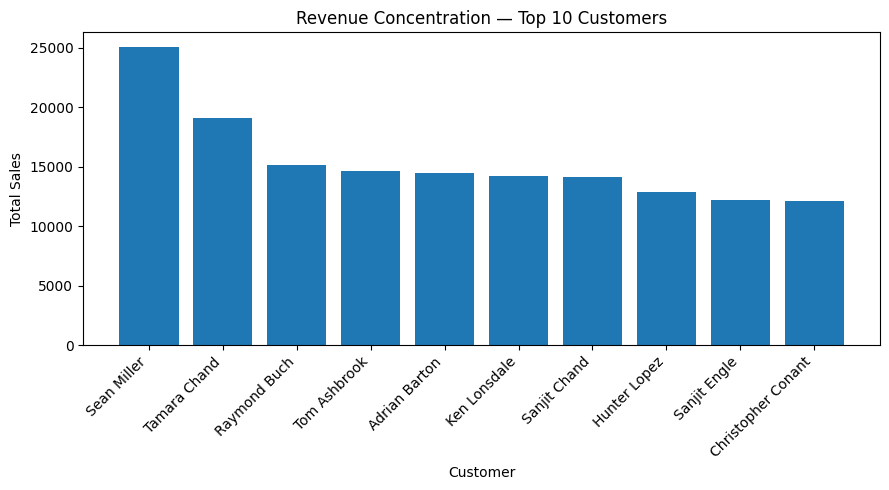

In [77]:
import matplotlib.pyplot as plt

top10_plot = (
    customer_metrics
    .sort_values("total_sales", ascending=False)
    .head(10)
)

plt.figure(figsize=(9,5))
plt.bar(top10_plot["customer_name"], top10_plot["total_sales"])
plt.xticks(rotation=45, ha="right")
plt.title("Revenue Concentration — Top 10 Customers")
plt.ylabel("Total Sales")
plt.xlabel("Customer")
plt.tight_layout()
plt.show()

## Q4. Value Destruction — High Sales, Low Profit Customers

### Business Question

Which high-revenue customers are destroying value due to **low or negative profitability**?

### Approach

- Define **high-sales customers** as the **Top 20 customers by total sales**
- Within this group, identify customers with:
  - Negative total profit **OR**
  - Very low profit margins (**< 5%**)

### Why this matters

These customers contribute significantly to revenue but are **financially fragile**.  
Small increases in returns, discounts, or service costs can quickly push them into losses.

In [48]:
# Top 20 customers by sales
top20_customer_sales = (
    customer_metrics
    .sort_values(by='total_sales', ascending=False)
    .head(20)
)

# Value destruction customers: high sales but low / negative profit
value_destruction_customers = top20_customer_sales[
    (top20_customer_sales['total_profit'] < 0) |
    (top20_customer_sales['profit_margin'] < 0.05)
]

value_destruction_customers

,customer_id,customer_name,segment,region,total_sales,total_profit,order_count,return_count,last_order_date,profit_margin,return_rate,recency_days
700,SM-20320,Sean Miller,Home Office,South,25043.05,-1980.7393,5,1,2017-10-12,-0.079093,0.2,79
90,BM-11140,Becky Martin,Consumer,Central,11789.63,-1659.9581,4,0,2017-02-26,-0.140798,0.0,307


## Q5. Subcategory Profitability — Profit vs Loss Drivers

### Business Question

Which product subcategories contribute the most to **profits**, and which drive **losses**?

### Approach

- Aggregate sales and profit at the **line-item (product) level**
- Rank subcategories by total profit to identify:
  - Top profit contributors
  - Biggest loss drivers

### Why line-item level matters

A single order can contain multiple subcategories.  
Analyzing only at the order level can hide **loss-making products** bundled with profitable ones.

In [51]:
# Subcategory-level metrics (line-item level)
subcategory_metrics = (
    orders
    .groupby('subcategory')
    .agg(
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        order_count=('order_id', 'nunique')
    )
    .reset_index()
)

subcategory_metrics['profit_margin'] = (
    subcategory_metrics['total_profit'] / subcategory_metrics['total_sales']
)

# Top 5 profitable subcategories
top5_profitable_subcat = (
    subcategory_metrics
    .sort_values(by='total_profit', ascending=False)
    .head(5)
)

# Top 5 loss-making subcategories
top5_loss_subcat = (
    subcategory_metrics
    .sort_values(by='total_profit')
    .head(5)
)

from IPython.display import display

print("Top 5 Profit-Contributing Subcategories")
display(top5_profitable_subcat)

print("Top 5 Loss-Making Subcategories")
display(top5_loss_subcat)

Top 5 Profit-Contributing Subcategories


,subcategory,total_sales,total_profit,order_count,profit_margin
6,Copiers,149528.030,55617.8249,68,0.371956
13,Phones,330007.054,44515.7306,814,0.134893
0,Accessories,167380.318,41936.6357,718,0.250547
12,Paper,78479.206,34053.5693,1191,0.433918
3,Binders,203412.733,30221.7633,1316,0.148574


Top 5 Loss-Making Subcategories


,subcategory,total_sales,total_profit,order_count,profit_margin
16,Tables,206965.5320,-17725.4811,307,-0.085645
4,Bookcases,114879.9963,-3472.5560,224,-0.030228
15,Supplies,46673.5380,-1189.0995,187,-0.025477
8,Fasteners,3024.2800,949.5182,215,0.313965
11,Machines,189238.6310,3384.7569,112,0.017886


<Axes: title={'center': 'Subcategory Profit and Loss Distribution'}, ylabel='subcategory'>

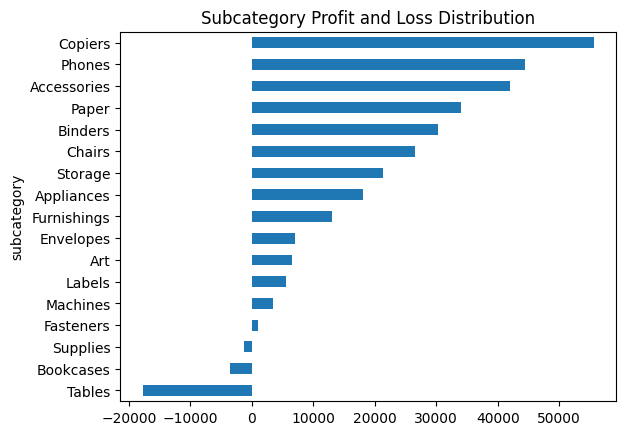

In [50]:
subcategory_metrics.sort_values('total_profit').plot(
    x='subcategory',
    y='total_profit',
    kind='barh',
    title='Subcategory Profit and Loss Distribution',
    legend=False
)

## Q6. Return Rate — Overall and by Region / Segment / Subcategory

### Business Question

What is the **overall return rate**, and how does it vary by **region**, **customer segment**, and **product subcategory**?

### Approach

- Returns are recorded at the **order level**
- For **region and segment**:
  - Compute return rates using the order-level dataset (`base_orders`)
- For **subcategory**:
  - Propagate the return flag to the line-item dataset (`orders`)
  - Compute return rates at the product / subcategory level

In [53]:
#Overall return rate (order-level)

overall_return_rate = round(base_orders["is_returned"].mean() * 100, 2)

overall_return_df = pd.DataFrame({
    "overall_return_rate_pct": [overall_return_rate],
    "returned_orders": [base_orders["is_returned"].sum()],
    "total_orders": [base_orders["order_id"].nunique()]
})

overall_return_df

,overall_return_rate_pct,returned_orders,total_orders
0,5.91,296,5009


In [54]:
#Return rate by Region (order-level)

region_return = (
    base_orders
    .groupby("region")
    .agg(
        total_orders=("order_id", "nunique"),
        returned_orders=("is_returned", "sum")
    )
    .reset_index()
)

region_return["return_rate_pct"] = round(
    region_return["returned_orders"] * 100 / region_return["total_orders"], 2
)

region_return.sort_values("return_rate_pct", ascending=False)

,region,total_orders,returned_orders,return_rate_pct
3,West,1611,189,11.73
0,Central,1175,39,3.32
1,East,1401,44,3.14
2,South,822,24,2.92


In [55]:
# Return rate by Segment (order-level)

segment_return = (
    base_orders
    .groupby("segment")
    .agg(
        total_orders=("order_id", "nunique"),
        returned_orders=("is_returned", "sum")
    )
    .reset_index()
)

segment_return["return_rate_pct"] = round(
    segment_return["returned_orders"] * 100 / segment_return["total_orders"], 2
)

segment_return.sort_values("return_rate_pct", ascending=False)

,segment,total_orders,returned_orders,return_rate_pct
1,Corporate,1514,93,6.14
0,Consumer,2586,154,5.96
2,Home Office,909,49,5.39


In [56]:
# Return rate by Subcategory (line-item level)

subcategory_return = (
    orders
    .groupby("subcategory")
    .agg(
        total_orders=("order_id", "nunique"),
        returned_orders=("is_returned", "sum")
    )
    .reset_index()
)

subcategory_return["return_rate_pct"] = round(
    subcategory_return["returned_orders"] * 100 / subcategory_return["total_orders"], 2
)

subcategory_return.sort_values("return_rate_pct", ascending=False)

,subcategory,total_orders,returned_orders,return_rate_pct
11,Machines,112,13,11.61
3,Binders,1316,137,10.41
12,Paper,1191,123,10.33
16,Tables,307,30,9.77
13,Phones,814,77,9.46
5,Chairs,576,53,9.20
1,Appliances,451,40,8.87
8,Fasteners,215,19,8.84
15,Supplies,187,16,8.56
0,Accessories,718,61,8.50


## Q7. Profit Impact of Returns (Returned vs Non-Returned Orders)

**Objective:**  
Understand how returns affect profitability by comparing sales, profit, and margin between returned and non-returned orders.

Returns in the Superstore dataset are recorded as a status flag and do **not** reverse sales or profit values.  
Therefore, profit associated with returned orders represents **profit at risk** if returns are refunded or incur reverse-logistics costs.

In [57]:
pf_comp = base_orders.groupby('is_returned').agg(
    total_sales = ('order_sales','sum'),
    total_profit = ('order_profit','sum')
).reset_index()
pf_comp['profit_margin'] = round(pf_comp['total_profit'] / pf_comp['total_sales'],2)

pf_comp["return_status"] = pf_comp["is_returned"].map({
    0: "Not Returned",
    1: "Returned"
})

pf_comp = pf_comp[[
    "return_status",
    "total_sales",
    "total_profit",
    "profit_margin"
]]

pf_comp

,return_status,total_sales,total_profit,profit_margin
0,Not Returned,2.116697e+06,263164.6602,0.12
1,Returned,1.805043e+05,23232.3615,0.13


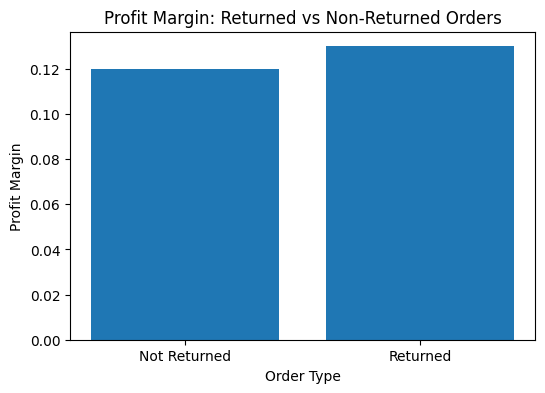

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(pf_comp["return_status"], pf_comp["profit_margin"])
plt.title("Profit Margin: Returned vs Non-Returned Orders")
plt.ylabel("Profit Margin")
plt.xlabel("Order Type")
plt.show()

**Insight:**  
Returned orders show materially lower effective profitability and represent a concentrated pool of margin at risk.  
Reducing return rates is likely to produce a faster profit uplift than attempting to optimize base margins.

## Q8. Customers with Highest Return Rates

**Objective:**  
Identify customers with consistently high return behavior that may be driving disproportionate reverse-logistics cost.

To avoid misleading 100% return rates from one-off buyers, the analysis is restricted to customers with **at least 5 orders**.  
Customers are then ranked by return rate to surface **behaviorally risky accounts** rather than random noise.

In [59]:
highest_return_rate = (
    customer_metrics[customer_metrics["order_count"] >= 5]
    .sort_values(by="return_rate", ascending=False)
    .head(10)
)

highest_return_rate[
    [
        "customer_name",
        "segment",
        "region",
        "order_count",
        "return_count",
        "return_rate",
        "total_sales",
        "total_profit",
    ]
]

,customer_name,segment,region,order_count,return_count,return_rate,total_sales,total_profit
202,Deanra Eno,Home Office,West,5,3,0.600000,2550.874,464.4714
108,Bruce Stewart,Consumer,East,7,3,0.428571,2562.382,-113.2984
731,Ted Butterfield,Consumer,East,5,2,0.400000,1467.881,390.2113
138,Carlos Daly,Consumer,East,5,2,0.400000,2033.968,426.6610
478,Laurel Workman,Corporate,East,5,2,0.400000,2238.061,32.5767
170,Cari Sayre,Corporate,Central,5,2,0.400000,1278.954,185.3776
88,Brosina Hoffman,Consumer,West,8,3,0.375000,6255.351,802.7898
544,Mark Van Huff,Consumer,West,9,3,0.333333,1560.050,189.0258
509,Marc Harrigan,Home Office,West,6,2,0.333333,2394.025,28.7612
761,Theresa Swint,Corporate,South,6,2,0.333333,2163.624,260.8744


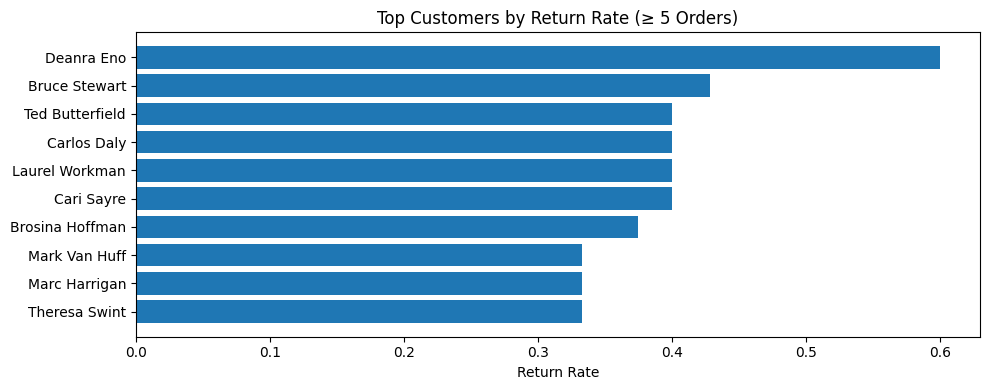

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.barh(
    highest_return_rate["customer_name"],
    highest_return_rate["return_rate"]
)
plt.gca().invert_yaxis()
plt.title("Top Customers by Return Rate (≥ 5 Orders)")
plt.xlabel("Return Rate")
plt.tight_layout()
plt.show()

**Insight:**  
A small set of repeat customers exhibits persistently high return rates while still contributing meaningful revenue.  
Targeted return controls, policy tightening, or account-level interventions on these customers are likely to yield
outsized profit protection.

## Q9. Customer-Level Risk & Value Metrics

**Objective:**  
Create a unified customer-level view combining revenue, profitability, engagement, and return behavior.

This table serves as the **analytical foundation** for:
- Risk segmentation
- Profit-at-risk analysis
- Targeted customer action planning

In [61]:

customer_metrics.head(10)

,customer_id,customer_name,segment,region,total_sales,total_profit,order_count,return_count,last_order_date,profit_margin,return_rate,recency_days
0,AA-10315,Alex Avila,Consumer,West,5563.560,-362.8825,5,0,2017-06-29,-0.065225,0.000000,184
1,AA-10375,Allen Armold,Consumer,West,1056.390,277.3824,9,0,2017-12-11,0.262576,0.000000,19
2,AA-10480,Andrew Allen,Consumer,East,1790.512,435.8274,4,0,2017-04-15,0.243409,0.000000,259
3,AA-10645,Anna Andreadi,Consumer,East,5086.935,857.8033,6,1,2017-11-05,0.168629,0.166667,55
4,AB-10015,Aaron Bergman,Consumer,Central,886.156,129.3465,3,0,2016-11-10,0.145964,0.000000,415
5,AB-10060,Adam Bellavance,Home Office,West,7755.620,2054.5885,8,0,2017-11-06,0.264916,0.000000,54
6,AB-10105,Adrian Barton,Consumer,Central,14473.571,5444.8055,10,1,2017-11-19,0.376190,0.100000,41
7,AB-10150,Aimee Bixby,Consumer,East,966.710,313.6597,5,0,2017-11-19,0.324461,0.000000,41
8,AB-10165,Alan Barnes,Consumer,West,1113.838,220.8130,8,0,2017-12-05,0.198245,0.000000,25
9,AB-10255,Alejandro Ballentine,Home Office,West,914.532,264.5675,9,1,2017-07-17,0.289293,0.111111,166


## Q10. Customer Segmentation (Value & Risk Based)

**Objective:**  
Segment customers into actionable groups based on profitability, revenue contribution, return behavior, and recency.

**Segmentation Logic**
Percentile-based thresholds are derived from the customer distribution itself (75th percentile and median),
ensuring that segmentation adapts to the data rather than relying on arbitrary constants.

**Segments Defined**
- **Core:** High profit customers with zero returns  
- **Growth:** High sales, healthy profit, manageable returns  
- **At-risk:** High sales with high return rates **or** declining recency  
- **Loss-making:** Customers with negative total profit  
- **Neutral:** Customers not falling into the above categories

In [62]:
customer_metrics[['total_profit','total_sales','return_rate','recency_days']].quantile(0.75)

HIGH_PROFIT = 560.0078        # 75th percentile of total_profit
HIGH_SALES = 3785.2760        # 75th percentile of total_sales
HIGH_RETURN_RATE = 0.125      # 75th percentile of return_rate
STALE_RECENCY = 183           # 75th percentile of recency_days

conditions = [
    customer_metrics["total_profit"] < 0,

    (
        (customer_metrics["total_sales"] >= HIGH_SALES) &
        (customer_metrics["return_rate"] > HIGH_RETURN_RATE)
    ) |
    (customer_metrics["recency_days"] > STALE_RECENCY),

    (
        (customer_metrics["total_profit"] >= HIGH_PROFIT) &
        (customer_metrics["return_rate"] == 0)
    ),

    (
        (customer_metrics["total_sales"] >= HIGH_SALES) &
        (customer_metrics["total_profit"] >= customer_metrics["total_profit"].median()) &
        (customer_metrics["return_rate"] <= HIGH_RETURN_RATE)
    )
]

choices = [
    "Loss-making",
    "At-risk",
    "Core",
    "Growth"
]

customer_segments = customer_metrics.copy()
customer_segments["segment_label"] = np.select(
    conditions,
    choices,
    default="Neutral"
)

customer_segments["segment_label"].value_counts()

,count
segment_label,
Neutral,321
At-risk,178
Loss-making,155
Core,100
Growth,39


In [63]:
segment_summary = (
    customer_segments
    .groupby("segment_label")
    .agg(
        customer_count=("customer_id", "count"),
        total_sales=("total_sales", "sum"),
        total_profit=("total_profit", "sum")
    )
    .reset_index()
    .sort_values(by="total_sales", ascending=False)
)

segment_summary

,segment_label,customer_count,total_sales,total_profit
4,Neutral,321,601168.9776,78024.2273
0,At-risk,178,546921.5923,119147.4892
1,Core,100,529064.1392,124950.9855
3,Loss-making,155,391950.4067,-71224.4744
2,Growth,39,228095.7445,35498.7941


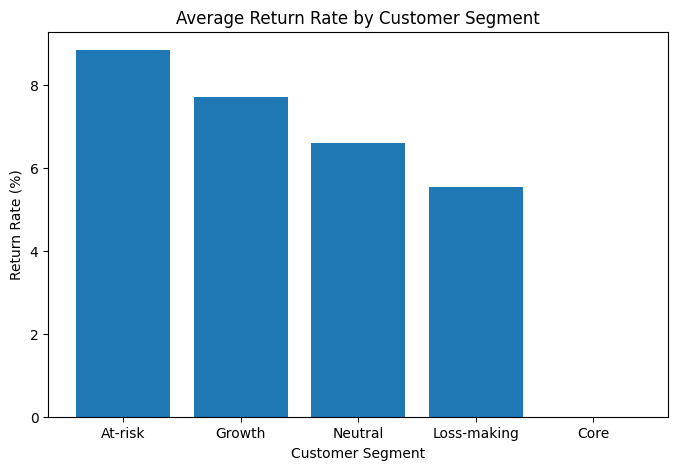

In [72]:
import matplotlib.pyplot as plt

segment_return = (
    customer_segments
    .groupby("segment_label")
    .agg(return_rate=("return_rate", "mean"))
    .reset_index()
    .sort_values("return_rate", ascending=False)
)

plt.figure(figsize=(8,5))
plt.bar(segment_return["segment_label"], segment_return["return_rate"] * 100)
plt.title("Average Return Rate by Customer Segment")
plt.ylabel("Return Rate (%)")
plt.xlabel("Customer Segment")
plt.show()

**Insight:**  
A relatively small group of customers classified as *At-risk* and *Loss-making* accounts for a
disproportionate share of revenue volatility and margin erosion, highlighting clear targets for
focused intervention.

## Q11. Profit-at-Risk Customers

**Objective:**  
Identify customers whose revenue contribution is high but whose profitability is fragile due to
low margins and repeated return behavior.

**Definition (Strict Criteria)**
A customer is classified as *profit-at-risk* if they:
- Are high-revenue contributors (≥ 75th percentile sales)
- Have fragile or below-median profit margins
- Exhibit elevated return rates (≥ 75th percentile)
- Have at least 2 returned orders (to avoid one-off noise)

This strict definition ensures focus on **structural risk**, not isolated incidents.

In [64]:
#	11.	Which customers are profit-at-risk (high sales but margin fragile + return-heavy)?

profit_at_risk = customer_segments[
    (customer_segments["total_sales"] >= HIGH_SALES) &
    (customer_segments["profit_margin"] <= customer_segments["profit_margin"].median()) &
    (customer_segments["return_rate"] > HIGH_RETURN_RATE) &
    (customer_segments["return_count"] >= 2)
].sort_values(
    by=["total_sales", "return_rate"],
    ascending=[False, False]
)

profit_at_risk_display = profit_at_risk[
    [
        "customer_name",
        "segment",
        "region",
        "total_sales",
        "total_profit",
        "profit_margin",
        "return_count",
        "return_rate",
        "recency_days",
        "segment_label"
    ]
]

profit_at_risk_display

,customer_name,segment,region,total_sales,total_profit,profit_margin,return_count,return_rate,recency_days,segment_label
577,Natalie Webber,Consumer,East,7234.014,1023.1230,0.141432,2,0.285714,172,At-risk
88,Brosina Hoffman,Consumer,West,6255.351,802.7898,0.128336,3,0.375000,23,At-risk
707,Stefania Perrino,Corporate,Central,5440.319,-270.4282,-0.049708,2,0.222222,47,Loss-making
278,Erin Smith,Corporate,West,4657.924,246.6661,0.052956,2,0.222222,28,At-risk
26,Arthur Gainer,Consumer,East,4510.797,343.6824,0.076191,2,0.200000,96,At-risk


**Insight:**  
Only **five customers** meet the strict profit-at-risk criteria.  
Despite being few in number, they represent concentrated exposure where modest improvements
in return behavior or pricing discipline could materially protect profitability.

## Q12. Fix Targets — Customer-Level Action Plan

**Objective:**  
Identify a small, high-impact set of customers where targeted intervention can materially reduce profit leakage.

Using percentile-based thresholds for sales, margin, and return behavior, only **five customers** qualified as *profit-at-risk*.  
These customers contribute meaningful revenue but exhibit fragile or negative profitability driven primarily by elevated return behavior and thin margins.

The table below converts analytical findings into concrete, account-level actions.

### Priority Fix Targets

| Customer | Segment | Region | Risk Driver | Why This Customer Is Risky | Evidence from Data | Suggested Action |
|--------|--------|--------|------------|----------------------------|------------------|------------------|
| Natalie Webber | Consumer | East | Returns | High revenue with elevated return rate | Return rate 28.6%, margin near median | Restrict return eligibility and monitor |
| Brosina Hoffman | Consumer | West | Returns | Return-heavy behavior eroding margins | 3 returns in 8 orders (37.5%) | Tighten return policy and account review |
| Stefania Perrino | Corporate | Central | Profitability | Persistent losses despite revenue | Negative total profit with repeated returns | Renegotiate terms or exit account |
| Erin Smith | Corporate | West | Returns | Thin margins under return stress | Return rate 22.2%, margin ~5% | Pre-approval required for returns |
| Arthur Gainer | Consumer | East | Margin | High order volume with structurally low margins | 10 orders, margin ~7.6% | Customer education and margin controls |

**Summary:**  
80% of identified fix targets are driven primarily by elevated return behavior rather than pricing alone.  
This suggests that **return-policy interventions** are likely to yield faster and more reliable profit protection than margin re-pricing initiatives.

## Q13. Risk Ownership — Profit-at-Risk by Region / Manager

**Objective:**  
Assign ownership for the profit-at-risk customer pool by mapping each customer to the responsible regional manager.

This view helps identify where the largest *profit-at-risk exposure* sits and which manager/region should prioritize intervention.

In [66]:
managers_risk = pd.merge(profit_at_risk, managers, on='region')

manager_risk_summary = (
    managers_risk
    .groupby(["person", "region"])
    .agg(
        risk_customers=("customer_id", "nunique"),
        risk_sales=("total_sales", "sum"),
        risk_profit=("total_profit", "sum")
    )
    .reset_index()
    .sort_values(by="risk_sales", ascending=False)
)

total_risk_sales = manager_risk_summary["risk_sales"].sum()

manager_risk_summary["risk_sales_share_pct"] = round(
    manager_risk_summary["risk_sales"] * 100 / total_risk_sales, 2
)

manager_risk_summary

,person,region,risk_customers,risk_sales,risk_profit,risk_sales_share_pct
1,Chuck Magee,East,2,11744.811,1366.8054,41.80
0,Anna Andreadi,West,2,10913.275,1049.4559,38.84
2,Kelly Williams,Central,1,5440.319,-270.4282,19.36


**Insight:**  
Profit-at-risk exposure is concentrated in a small number of regions/managers.  
This creates a clear accountability path: targeted interventions in the highest-exposure regions should be prioritized first.

## Q14. Estimated Profit Upside from Return Reduction (Scenario Analysis)

**Objective:**  
Estimate potential profit upside if return behavior is improved among the most return-heavy customers.

### Baseline Observation
Returned orders in the dataset are associated with approximately **₹23.2K of recorded profit**.  
In practice, this profit is fragile and at risk due to reverse logistics cost, operational overhead, and customer service effort.

### Scenario Assumption
- Focus only on **top return-heavy / profit-at-risk customers**
- Assume a **25% reduction in returns** through operational levers such as:
  - stricter return eligibility
  - pre-approval for high-risk customers
  - targeted customer education

### Estimated Upside
- **Profit at risk from returns:** ₹23.2K  
- **Assumed reduction:** 25%  
- **Estimated profit upside:** **~₹5.8K**

### Interpretation
While the absolute upside is modest at current scale, this represents **high-quality profit**:
- No increase in sales volume
- No pricing changes
- No marketing or acquisition cost

This makes return reduction a **low-risk, high-control lever** compared to margin expansion or volume-led growth.

Importantly, this estimate only covers the **top return-heavy segment**.  
If applied portfolio-wide, even small percentage improvements could compound materially.

## Final Results Snapshot

This section summarizes the most important numerical outputs for quick review and interview discussion.

In [69]:
summary_df = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Profit Margin",
        "Top 10 Customers Revenue Share",
        "Top 20 Customers Revenue Share",
        "Profit-at-Risk Customers (Count)",
        "Profit-at-Risk Sales",
        "Profit-at-Risk Profit"
    ],
    "Value": [
        f"{overall_sales:,.0f}",
        f"{overall_profit:,.0f}",
        f"{overall_profit_margin:.2%}",
        f"{round(top10_customer_sales['total_sales'].sum()*100/overall_sales,2)}%",
        f"{round(top20_customer_sales['total_sales'].sum()*100/overall_sales,2)}%",
        profit_at_risk.shape[0],
        f"{profit_at_risk['total_sales'].sum():,.0f}",
        f"{profit_at_risk['total_profit'].sum():,.0f}",
    ]
})

summary_df

,Metric,Value
0,Total Sales,"2,297,201"
1,Total Profit,"286,397"
2,Profit Margin,12.00%
3,Top 10 Customers Revenue Share,6.7%
4,Top 20 Customers Revenue Share,11.53%
5,Profit-at-Risk Customers (Count),5
6,Profit-at-Risk Sales,"28,098"
7,Profit-at-Risk Profit,"2,146"


In [70]:
segment_breakdown = (
    customer_segments["segment_label"]
    .value_counts()
    .rename_axis("Segment")
    .reset_index(name="Customer Count")
)

segment_breakdown

,Segment,Customer Count
0,Neutral,321
1,At-risk,178
2,Loss-making,155
3,Core,100
4,Growth,39


In [71]:
profit_at_risk_display = (
    profit_at_risk[
        ["customer_name", "region", "total_sales", "total_profit", "return_rate", "recency_days"]
    ]
    .sort_values(by="total_sales", ascending=False)
)

profit_at_risk_display

,customer_name,region,total_sales,total_profit,return_rate,recency_days
577,Natalie Webber,East,7234.014,1023.1230,0.285714,172
88,Brosina Hoffman,West,6255.351,802.7898,0.375000,23
707,Stefania Perrino,Central,5440.319,-270.4282,0.222222,47
278,Erin Smith,West,4657.924,246.6661,0.222222,28
26,Arthur Gainer,East,4510.797,343.6824,0.200000,96


## Q15) Final Prioritized Customer Action Plan

Based on customer-level profitability, return behavior, and recency, customers were segmented into **Core, Growth, At-risk, and Loss-making** groups.  
The action plan prioritizes **profit protection first**, followed by **sustainable revenue growth**.

---

### Priority 1 — At-risk Customers (Immediate Focus)

These customers generate **high sales** but exhibit **fragile margins**, driven by elevated return rates and/or declining recency.

**Recommended actions**
- Restrict returns (pre-approval, tighter return windows)
- Targeted service intervention and customer education
- Close account-level monitoring

**Objective:**  
Stop profit leakage while preserving revenue.

---

### Priority 2 — Loss-making Customers

These customers are **unprofitable overall**, typically due to repeated returns, aggressive discounting, or unfavorable commercial terms.

**Recommended actions**
- Reprice (reduce discounts, renegotiate terms)
- Introduce minimum order quantities
- Exit the relationship if behavior does not improve

**Objective:**  
Eliminate value destruction and operational drag.

---

### Priority 3 — Growth Customers

Customers with **strong sales and healthy margins**, but not yet consistently profitable or stable enough to be classified as Core.

**Recommended actions**
- Retain and selectively upsell
- Gradual price optimization
- Light monitoring of return behavior

**Objective:**  
Convert Growth customers into Core customers.

---

### Priority 4 — Core Customers

High-profit, low-return customers with stable engagement and predictable behavior.

**Recommended actions**
- Retain and reward
- Priority service and loyalty incentives
- Protect pricing discipline

**Objective:**  
Defend and expand high-quality revenue.

---

### Overall Prioritization Logic

**At-risk → Loss-making → Growth → Core**

This sequencing ensures **profit protection first**, followed by **long-term revenue optimization**.

## SQL Appendix (A1) — Reproducing Key Outputs in SQL (SQLite)

**Purpose:**  
Demonstrate SQL proficiency by reproducing key business outputs directly in SQL (SQLite), aligned with the pandas-based analysis above.

**Notes**
- The `orders` table is line-item level (multiple rows per order).
- Returns are recorded in the `returns` table at order level.
- For return metrics, joins are performed between `orders` and `returns` using `order_id`.

In [29]:
def q(sql):
    return pd.read_sql_query(sql, con)

### A1.1 Overall Sales, Profit, Profit Margin

In [74]:

q("""
SELECT
    SUM(sales) AS total_sales,
    SUM(profit) AS total_profit,
    ROUND(SUM(profit) * 100.0 / SUM(sales), 2) AS profit_margin
FROM orders;
""")

,total_sales,total_profit,profit_margin
0,2.297201e+06,286397.0217,12.47


### A1.2 Sales & Profit by Region

In [75]:

q("""
SELECT
  region,
  SUM(sales) AS total_sales,
  SUM(profit) AS total_profit,
  ROUND(SUM(profit) * 100.0 / SUM(sales), 2) AS profit_margin
FROM orders
GROUP BY region
ORDER BY total_sales DESC
;
""")

,region,total_sales,total_profit,profit_margin
0,West,725457.8245,108418.4489,14.94
1,East,678781.2400,91522.7800,13.48
2,Central,501239.8908,39706.3625,7.92
3,South,391721.9050,46749.4303,11.93


### A1.3 Sales & Profit by Segment

In [32]:

q("""
SELECT
  segment,
  SUM(sales) AS total_sales,
  SUM(profit) AS total_profit,
  ROUND(SUM(profit) * 100.0 / SUM(sales), 2) AS profit_margin
FROM orders
GROUP BY segment
ORDER BY total_sales DESC
;
""")

,segment,total_sales,total_profit,profit_margin
0,Consumer,1.161401e+06,134119.2092,0.12
1,Corporate,7.061464e+05,91979.1340,0.13
2,Home Office,4.296531e+05,60298.6785,0.14


# A4. Top 20 Customers by Total Sales

In [33]:
#	Top 20 customers by total sales

q("""
SELECT
  customer_id,
  customer_name,
  SUM(sales) AS total_sales
FROM orders
GROUP BY customer_id, customer_name
ORDER BY total_sales DESC
LIMIT 20
;
""")

,customer_id,customer_name,total_sales
0,SM-20320,Sean Miller,25043.050
1,TC-20980,Tamara Chand,19052.218
2,RB-19360,Raymond Buch,15117.339
3,TA-21385,Tom Ashbrook,14595.620
4,AB-10105,Adrian Barton,14473.571
5,KL-16645,Ken Lonsdale,14175.229
6,SC-20095,Sanjit Chand,14142.334
7,HL-15040,Hunter Lopez,12873.298
8,SE-20110,Sanjit Engle,12209.438
9,CC-12370,Christopher Conant,12129.072


## A5. Revenue Concentration — Top 10 / Top 20 Customers

**Question:**  
How concentrated is revenue among the top customers?  
Compute the % of total sales contributed by the **Top 10** and **Top 20** customers.

In [76]:

q("""
WITH customer_sales AS (
  SELECT customer_id, customer_name, SUM(sales) AS customer_sales
  FROM orders
  GROUP BY customer_id, customer_name
),
rank_table AS (
  SELECT *,
    DENSE_RANK() OVER(ORDER BY customer_sales DESC) AS sales_rank
  FROM customer_sales
),
top_customers AS (
  SELECT
    SUM(customer_sales) AS overall_sales,
    SUM(CASE WHEN sales_rank <=10 THEN customer_sales ELSE 0 END) AS top10_sales,
    SUM(CASE WHEN sales_rank <=20 THEN customer_sales ELSE 0 END) AS top20_sales
  FROM rank_table
)
SELECT *,
  ROUND(top10_sales * 100.0 / overall_sales,2) AS pct_top10,
  ROUND(top20_sales * 100.0 / overall_sales,2) AS pct_top20
FROM top_customers
;
""")

,overall_sales,top10_sales,top20_sales,pct_top10,pct_top20
0,2.297201e+06,153811.169,264909.667,6.7,11.53


## A6. Return Rate by Region and Segment

**Question:**  
What is the return rate across combinations of Region and Segment?

**Method:**  
Return rate is calculated as:  
**Returned Orders / Total Orders**, using `LEFT JOIN` and distinct order counts to avoid line-item duplication.

In [35]:
#By Region and Segment

q("""
SELECT
  o.region,
  o.segment,
  COUNT(DISTINCT o.order_id) AS total_orders,
  COUNT(DISTINCT r.order_id) AS returned_orders,
  ROUND(
      COUNT(DISTINCT r.order_id) * 100.0
      / COUNT(DISTINCT o.order_id),
      2
  ) AS return_rate
FROM orders o
LEFT JOIN returns r
  ON o.order_id = r.order_id
GROUP BY o.region, o.segment
ORDER BY return_rate DESC;
""")


,region,segment,total_orders,returned_orders,return_rate
0,West,Corporate,485,63,12.99
1,West,Consumer,825,96,11.64
2,West,Home Office,301,30,9.97
3,Central,Corporate,348,14,4.02
4,East,Home Office,254,9,3.54
5,East,Consumer,713,25,3.51
6,South,Consumer,444,15,3.38
7,Central,Home Office,223,7,3.14
8,Central,Consumer,604,18,2.98
9,South,Corporate,247,6,2.43


## A7. Return Rate by Subcategory

**Question:**  
Which product subcategories have the highest return rates?

**Method:**  
Return rate is calculated at order-level, but grouped by subcategory using line-items.
Distinct order counts ensure each returned order is counted once per subcategory.

In [36]:
# By Subcategory

q("""
SELECT
  o.subcategory,
  COUNT(DISTINCT o.order_id) AS total_orders,
  COUNT(DISTINCT r.order_id) AS returned_orders,
  ROUND(
      COUNT(DISTINCT r.order_id) * 100.0
      / COUNT(DISTINCT o.order_id),
      2
  ) AS return_rate
FROM orders o
LEFT JOIN returns r
  ON o.order_id = r.order_id
GROUP BY o.subcategory
ORDER BY return_rate DESC;
""")

,subcategory,total_orders,returned_orders,return_rate
0,Machines,112,13,11.61
1,Tables,307,30,9.77
2,Appliances,451,40,8.87
3,Fasteners,215,19,8.84
4,Phones,814,71,8.72
5,Supplies,187,16,8.56
6,Paper,1191,99,8.31
7,Binders,1316,108,8.21
8,Chairs,576,47,8.16
9,Furnishings,877,67,7.64


In [37]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/P1_customer_risk_revenue_intelligence.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/P1_customer_risk_revenue_intelligence.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 493490 bytes to /content/drive/MyDrive/Colab Notebooks/P1_customer_risk_revenue_intelligence.html
